Image Information:
Dimensions: (1207, 1207, 3)
Data Type: uint8
Pixel Value Range: [0, 253]


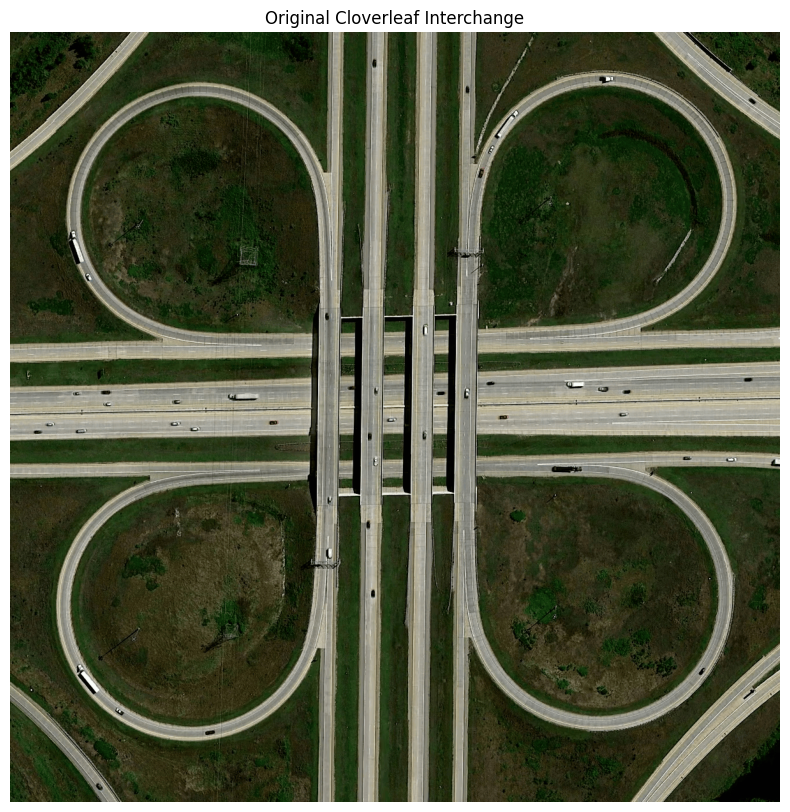

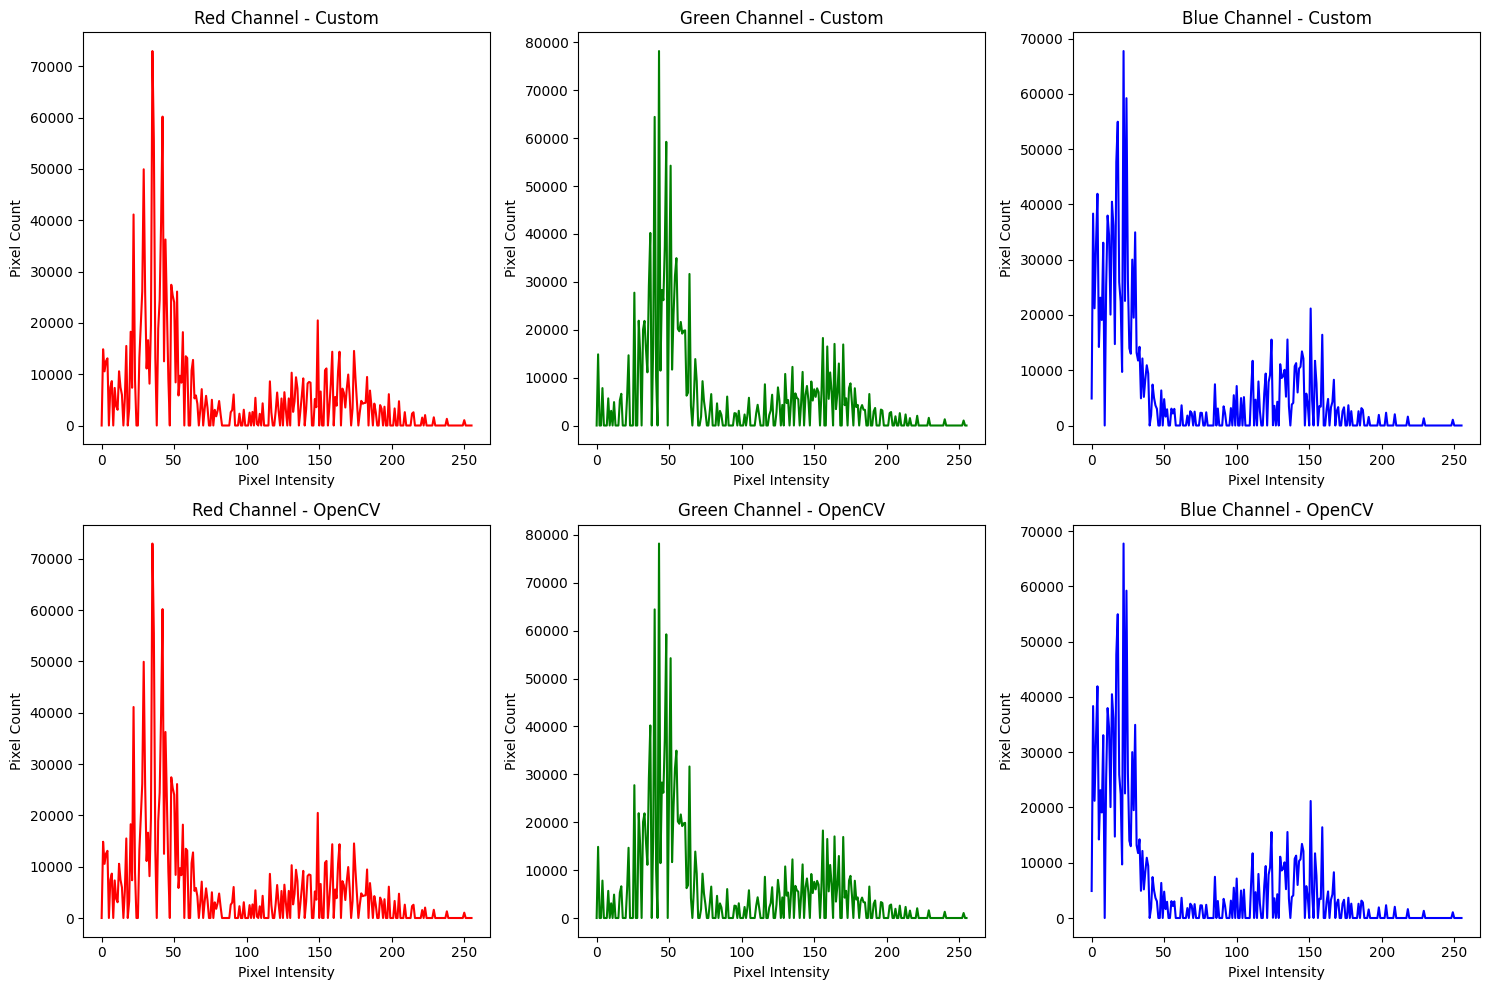


Red Channel Comparison:
Custom Sum: 1456849
OpenCV Sum: 1456849.0
Max Absolute Difference: 0.0
Methods Equivalent: True

Green Channel Comparison:
Custom Sum: 1456849
OpenCV Sum: 1456849.0
Max Absolute Difference: 0.0
Methods Equivalent: True

Blue Channel Comparison:
Custom Sum: 1456849
OpenCV Sum: 1456849.0
Max Absolute Difference: 0.0
Methods Equivalent: True


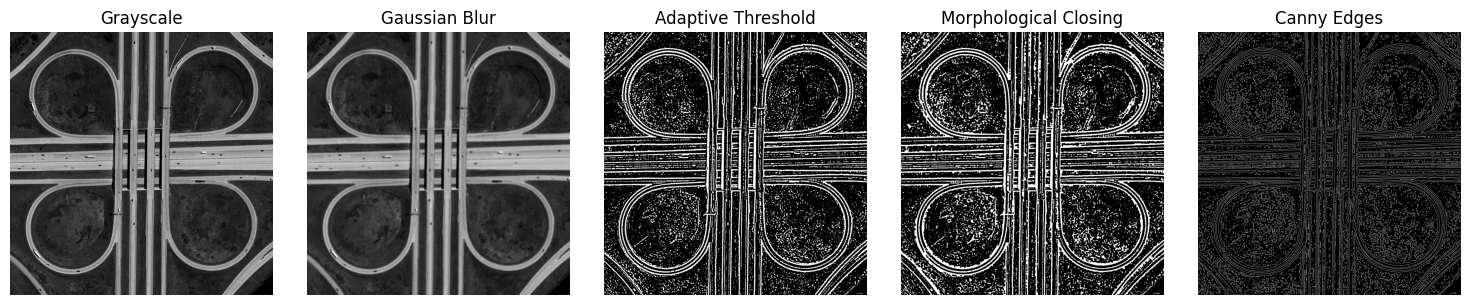

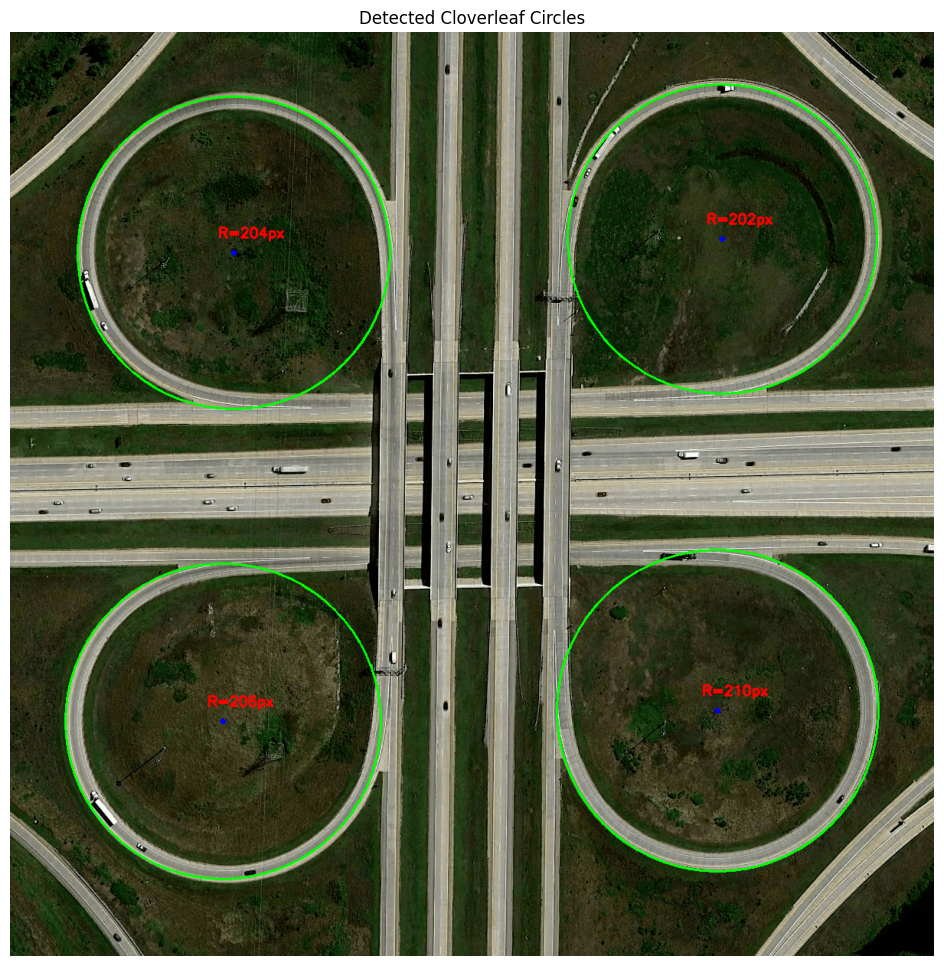


Detected Circle Radii:
Circle 1: 206 pixels
Circle 2: 210 pixels
Circle 3: 204 pixels
Circle 4: 202 pixels

Circle Areas (square pixels):
Circle 1: 133316.63
Circle 2: 138544.24
Circle 3: 130740.52
Circle 4: 128189.55


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def preprocess_image(image):
    """
    Preprocess the image with multiple steps and visualize each stage.
    
    Args:
        image (numpy.ndarray): Input RGB image
    
    Returns:
        numpy.ndarray: Preprocessed image ready for circle detection
    """
    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    plt.figure(figsize=(15, 3))
    plt.subplot(151)
    plt.title('Grayscale')
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    
    # Step 2: Apply Gaussian blur to reduce noise
    # Justification: Helps reduce high-frequency noise while preserving edges
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    plt.subplot(152)
    plt.title('Gaussian Blur')
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')
    
    # Step 3: Apply adaptive thresholding
    # Justification: Handles varying lighting conditions better than global thresholding
    thresh = cv2.adaptiveThreshold(
        blurred, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )
    plt.subplot(153)
    plt.title('Adaptive Threshold')
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')
    
    # Step 4: Morphological operations to clean up the image
    # Justification: Closes small gaps and removes noise
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    plt.subplot(154)
    plt.title('Morphological Closing')
    plt.imshow(cleaned, cmap='gray')
    plt.axis('off')
    
    # Step 5: Edge detection (Canny)
    # Justification: Helps in identifying circle boundaries
    edges = cv2.Canny(cleaned, 50, 150)
    plt.subplot(155)
    plt.title('Canny Edges')
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return cleaned

def detect_cloverleaves(image, preprocessed):
    """
    Detect circular structures in the preprocessed image.
    
    Args:
        image (numpy.ndarray): Original RGB image
        preprocessed (numpy.ndarray): Preprocessed grayscale image
    
    Returns:
        tuple: Visualization image and detected circles
    """
    # Hough Circle Transform with carefully tuned parameters
    circles = cv2.HoughCircles(
        preprocessed,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,  # Minimum distance between circle centers
        param1=50,    # Higher threshold for edge detection
        param2=30,    # Accumulator threshold for circle detection
        minRadius=195,  # Minimum expected radius
        maxRadius=220   # Maximum expected radius
    )
    
    # Create output image for visualization
    output = image.copy()
    
    if circles is not None:
        circles = np.uint16(np.around(circles))
        return output, circles[0]
    return output, None

def calculate_area(circles):
    """
    Calculate areas of detected circles.
    
    Args:
        circles (numpy.ndarray): Detected circle parameters
    
    Returns:
        list: Areas of detected circles
    """
    areas = []
    if circles is not None:
        for circle in circles:
            radius = circle[2]
            area = np.pi * (radius ** 2)
            areas.append(area)
    return areas

def visualize_results(image, circles):
    """
    Visualize detected circles with centers and radii.
    
    Args:
        image (numpy.ndarray): Original RGB image
        circles (numpy.ndarray): Detected circle parameters
    
    Returns:
        numpy.ndarray: Image with circles and labels
    """
    output = image.copy()
    if circles is not None:
        for idx, (x, y, r) in enumerate(circles):
            # Draw the outer circle
            cv2.circle(output, (x, y), r, (0, 255, 0), 2)
            # Draw the center
            cv2.circle(output, (x, y), 2, (0, 0, 255), 3)
            # Add label
            cv2.putText(output, f'R={r}px', (x-20, y-20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return output


def load_cloverleaf_image(image_path):
    """
    Load image and provide detailed information
    
    Args:
        image_path (str): Path to input image
    
    Returns:
        numpy.ndarray: Loaded RGB image
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not load image")
    
    # Convert to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Image information
    print("Image Information:")
    print(f"Dimensions: {image.shape}")
    print(f"Data Type: {image.dtype}")
    print(f"Pixel Value Range: [{np.min(image)}, {np.max(image)}]")
    
    # Display original image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.title('Original Cloverleaf Interchange')
    plt.axis('off')
    plt.show()
    
    return image_rgb

class HistogramAnalyzer:
    @staticmethod
    def custom_histogram(image):
        """
        Manually calculate histogram for each color channel
        
        Args:
            image (np.ndarray): Input RGB image
        
        Returns:
            list: Histograms for R, G, B channels
        """
        # Initialize histogram arrays
        histograms = []
        
        # Calculate histogram for each channel
        for channel in range(3):
            # Create histogram array
            hist = np.zeros(256, dtype=int)
            
            # Manually count pixel intensities
            for pixel_value in image[:,:,channel].ravel():
                hist[pixel_value] += 1
            
            histograms.append(hist)
        
        return histograms
    
    @staticmethod
    def opencv_histogram(image):
        """
        Calculate histogram using OpenCV
        
        Args:
            image (np.ndarray): Input RGB image
        
        Returns:
            list: Histograms for R, G, B channels
        """
        histograms = []
        
        # Calculate histogram for each channel
        for channel in range(3):
            hist = cv2.calcHist([image], [channel], None, [256], [0, 256])
            histograms.append(hist.flatten())
        
        return histograms
    
    @classmethod
    def compare_histograms(cls, image):
        """
        Compare custom and OpenCV histogram calculations
        
        Args:
            image (np.ndarray): Input RGB image
        """
        # Calculate histograms
        custom_hist = cls.custom_histogram(image)
        opencv_hist = cls.opencv_histogram(image)
        
        # Visualization
        plt.figure(figsize=(15, 10))
        colors = ['red', 'green', 'blue']
        channel_names = ['Red', 'Green', 'Blue']
        
        for i in range(3):
            plt.subplot(2, 3, i+1)
            plt.title(f'{channel_names[i]} Channel - Custom')
            plt.plot(custom_hist[i], color=colors[i])
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Pixel Count')
            
            plt.subplot(2, 3, i+4)
            plt.title(f'{channel_names[i]} Channel - OpenCV')
            plt.plot(opencv_hist[i], color=colors[i])
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Pixel Count')
        
        plt.tight_layout()
        plt.show()
        
        # Verification
        for i in range(3):
            print(f"\n{channel_names[i]} Channel Comparison:")
            print("Custom Sum:", np.sum(custom_hist[i]))
            print("OpenCV Sum:", np.sum(opencv_hist[i]))
            max_diff = np.max(np.abs(custom_hist[i] - opencv_hist[i]))
            print(f"Max Absolute Difference: {max_diff}")
            print("Methods Equivalent:", np.array_equal(custom_hist[i], opencv_hist[i]))

def main():
    # Load image
    image_path = './../Dataset/cloverleaf_interchange.png'
    image = load_cloverleaf_image('./../Dataset/cloverleaf_interchange.png')
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Perform histogram comparison
    HistogramAnalyzer.compare_histograms(image_rgb)

    preprocessed = preprocess_image(image_rgb)
    
    # Detect circles
    output, circles = detect_cloverleaves(image, preprocessed)
    
    if circles is not None:
        
        
        # Visualize results
        result = visualize_results(image_rgb, circles)
        
        # Display result
        plt.figure(figsize=(12, 12))
        plt.imshow(result)
        plt.title('Detected Cloverleaf Circles')
        plt.axis('off')
        plt.show()

        # Print radii
        print("\nDetected Circle Radii:")
        for idx, circle in enumerate(circles):
            print(f"Circle {idx + 1}: {circle[2]} pixels")
        
        # Calculate and print areas
        areas = calculate_area(circles)
        print("\nCircle Areas (square pixels):")
        for idx, area in enumerate(areas):
            print(f"Circle {idx + 1}: {area:.2f}")

    else:
        print("No circles detected!")


if __name__ == "__main__":
    main()

# Cloverleaf Structure Detection and Analysis

## Preprocessing Techniques and Justification

### Grayscale Conversion
- **Justification**: Simplifies processing by removing color information. Cloverleaf structures are defined primarily by shape and edges, making color data unnecessary.

### Gaussian Blur
- **Justification**: Reduces high-frequency noise and small irregularities while preserving edge structures. This enhances the circular shapes of the cloverleaves by smoothing minor distortions.

### Adaptive Thresholding
- **Justification**: Handles variations in lighting across the image. This is essential for detecting cloverleaf structures under uneven illumination conditions.

### Morphological Closing
- **Justification**: Fills small gaps and removes noise within cloverleaf structures. Helps connect segments to form more complete circular shapes.

### Canny Edge Detection
- **Justification**: Highlights boundaries of cloverleaf structures for subsequent circle detection, enabling accurate location and measurement of circular shapes.

---

## Impact of Preprocessing Techniques and Suitability for Detection
The preprocessing pipeline emphasizes cloverleaf structures and reduces unwanted details:
- Grayscale conversion, Gaussian blur, and adaptive thresholding simplify the image and highlight circular shapes.
- Morphological closing refines shapes by removing gaps and irregularities.
- Canny edge detection provides clear outlines for accurate circle detection.

---

## Circle Detection Method and Parameter Choices

### Hough Circle Transform Parameters
- **dp = 1**: Accumulator and image resolutions are the same.
- **minDist = 100**: Minimum distance between detected circle centers to avoid duplicates.
- **param1 = 50**: Higher threshold for the Canny edge detector to filter weak edges.
- **param2 = 30**: Threshold for circle detection; balances sensitivity and accuracy.
- **minRadius = 195**: Minimum expected radius of cloverleaf circles.
- **maxRadius = 220**: Maximum expected radius of cloverleaf circles.

**Rationale**: These parameters were tuned to detect quarter-and-a-half circle shapes characteristic of cloverleaf interchanges.

---

## Challenges and Limitations
1. **Complex Background**: Roads, vegetation, and other structures may interfere with detection despite preprocessing.
2. **Irregular Shapes**: Cloverleaf structures may not form perfect circles, leading to inaccuracies.
3. **Size Assumptions**: MinRadius and MaxRadius parameters may not account for significantly different cloverleaf sizes.
4. **Overlapping Structures**: Close or overlapping circles can affect detection accuracy.

---

## Radius Calculation and Potential Sources of Error

### Potential Sources of Error
1. **Preprocessing Accuracy**: Inadequate isolation or enhancement of cloverleaf structures affects detection.
2. **Circular Assumption**: Slight distortions in cloverleaf shapes can cause inaccuracies.
3. **Pixel Resolution**: Radius values depend on image resolution; real-world dimensions require additional scale information.
4. **Overlapping Structures**: Proximity of cloverleaves may hinder boundary accuracy.

---

## Area Calculation and Reporting
- Formula: \( Area = pi * r^2 \)
- Detected circle areas:
  - **Circle 1**: 133,316.63 square pixels
  - **Circle 2**: 138,544.24 square pixels
  - **Circle 3**: 130,740.52 square pixels
  - **Circle 4**: 128,189.55 square pixels

These areas provide quantitative measures of the size of each cloverleaf structure.
